# 02 — Träna Mustache-modellen
Tränar på vad som **just nu** ligger i `data/dataset_v3/`.

**Kör denna två gånger i workflowet:**
1. Första gången direkt efter `01_prepare_mustache_dataset.ipynb` — för att få en modell att hitta label noise med i `03_clean_mustache_dataset.ipynb`
2. Andra gången efter städningen i steg 03 — det blir din slutgiltiga modell

In [42]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

DATA_DIR  = 'data/dataset_v3'
IMG_SIZE  = (178, 178)
BATCH_SIZE = 32
MODEL_OUT = 'models/mustache_detector_3.keras'

print('TensorFlow:', tf.__version__)
print(f'Mustasch: {len(os.listdir(os.path.join(DATA_DIR, "mustache")))}')
print(f'Clean:    {len(os.listdir(os.path.join(DATA_DIR, "clean")))}')

TensorFlow: 2.16.2
Mustasch: 6185
Clean:    5679


## Ladda dataset

In [43]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print('Klasser:', train_ds.class_names)

Found 11863 files belonging to 2 classes.
Using 9491 files for training.
Found 11863 files belonging to 2 classes.
Using 2372 files for validation.
Klasser: ['clean', 'mustache']


## Bygg modellen
Custom CNN — fyra Conv2D-block + dropout. (MobileNetV2 testades men gav sämre resultat på den städade datan, se anteckning i README.)

In [44]:
def build_model():
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ])

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


model = build_model()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print('Modell byggd!')

Modell byggd!


## Träna

In [45]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop]
)

loss, acc = model.evaluate(val_ds)
print(f'\nAccuracy: {acc*100:.1f}%')

Epoch 1/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 133s 442ms/step - accuracy: 0.7144 - loss: 0.5349 - val_accuracy: 0.8567 - val_loss: 0.3340
Epoch 2/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 138s 464ms/step - accuracy: 0.8594 - loss: 0.3256 - val_accuracy: 0.8912 - val_loss: 0.2564
Epoch 3/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 124s 418ms/step - accuracy: 0.8959 - loss: 0.2502 - val_accuracy: 0.8891 - val_loss: 0.2600
Epoch 4/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 137s 460ms/step - accuracy: 0.9088 - loss: 0.2149 - val_accuracy: 0.9178 - val_loss: 0.1966
Epoch 5/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 130s 438ms/step - accuracy: 0.9245 - loss: 0.1847 - val_accuracy: 0.9212 - val_loss: 0.1898
Epoch 6/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 125s 421ms/step - accuracy: 0.9410 - loss: 0.1502 - val_accuracy: 0.9325 - val_loss: 0.1753
Epoch 7/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 129s 435ms/step - accuracy: 0.9441 - loss: 0.1397 - val_accuracy: 0.9393 - val_loss: 0.1606
Epoch 8/35
297/297 ━━━━━━━━━━━━━━━━━━━━ 140s 472ms/step - accuracy: 0.9501 -

## Utvärdering

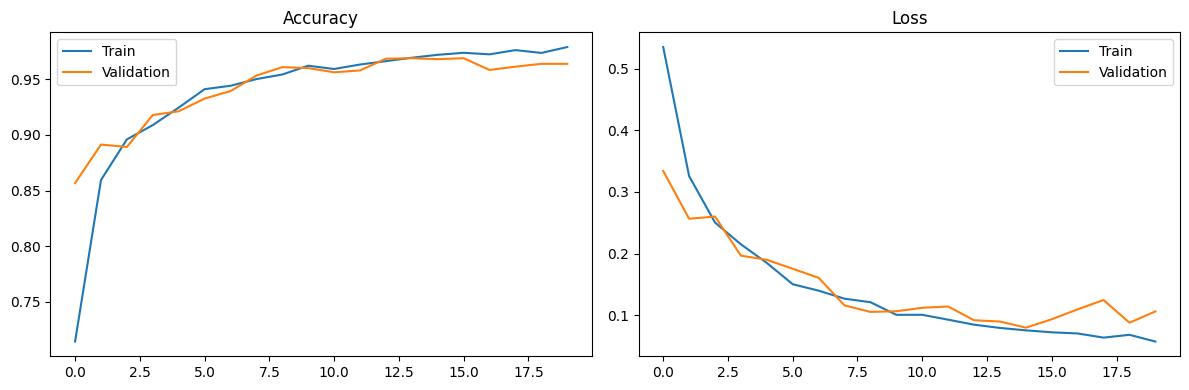

2026-06-26 23:30:53.921572: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


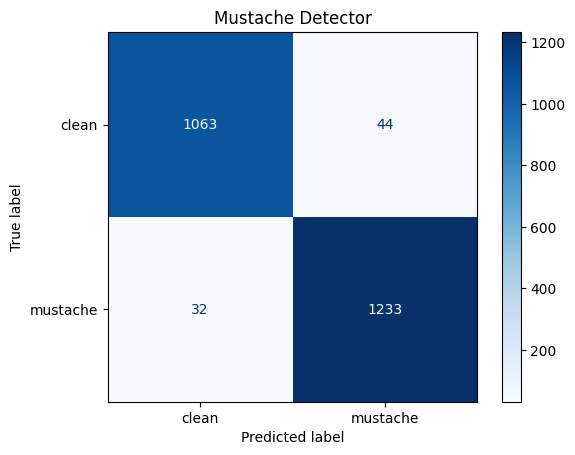

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
os.makedirs('presentation', exist_ok=True)
plt.savefig('presentation/training_curves_mustache.png', dpi=150, bbox_inches='tight')
plt.show()

y_true, y_pred = [], []
for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=val_ds.class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Mustache Detector')
plt.savefig('presentation/confusion_mustache.png', dpi=150, bbox_inches='tight')
plt.show()

## Spara
**OBS:** sparar `model` (den faktiska, tränade modellen i denna körning) — inte ett hårdkodat namn som kan peka på fel modell.

In [47]:
os.makedirs('models', exist_ok=True)
model.save(MODEL_OUT)
print(f'Sparad: {MODEL_OUT}')

Sparad: models/mustache_detector_3.keras
